# Access-pricing simulations


## Setup

In [4]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import integrate
from pathlib import Path

from model import *

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['text.usetex'] = False

FIGDIR = Path('figures'); FIGDIR.mkdir(exist_ok=True)
def fpath(n): return str(FIGDIR / n)


## Parameters and model-function shapes

Produces `f_func.pdf`.

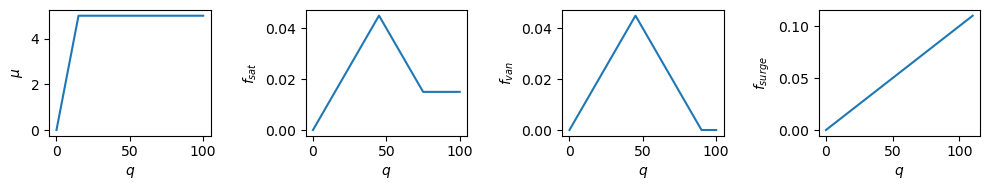

In [6]:
K_R, K_U   = 7, 1.5
mu_max     = 5
q_c, q_max = 15, 100
q_m, q_n   = 45, 75
beta       = 0.001
q1, q2     = 20, 85

qs = np.linspace(0, q_max, 1000)

plt.figure(figsize=(10, 2))
plt.subplot(1, 4, 1)
plt.plot(qs, mu(qs, q_c, q_max, mu_max))
plt.xlabel(r'$q$'); plt.ylabel(r'$\mu$')
plt.subplot(1, 4, 2)
plt.plot(qs, f_saturated(qs, q_m, q_n, beta))
plt.xlabel(r'$q$'); plt.ylabel(r'$f_{sat}$')
plt.subplot(1, 4, 3)
plt.plot(qs, f_saturated(qs, q_m, 2*q_m, beta))
plt.xlabel(r'$q$'); plt.ylabel(r'$f_{van}$')
plt.subplot(1, 4, 4)
plt.plot(np.linspace(0, q_max+10, 1000),
         f_surge(np.linspace(0, q_max+10, 1000), beta))
plt.xlabel(r'$q$'); plt.ylabel(r'$f_{surge}$')
plt.tight_layout()
plt.savefig(fpath('f_func.pdf'), format='pdf')
plt.show()


## Fig. 5 — saturated-price schematic

α is chosen as a cubic that passes above/through the equilibrium loci
associated with the surge and saturated pricing modes. Produces
`schematic_saturated2.pdf`.


In [8]:
# Hand-picked control points for the alpha cubic (matches the paper's Fig. 5)
alpha_ctrl_x = np.array([0, 40, 75, q_max])
alpha_ctrl_y = np.array([0.05, 0.04, 0.02, 0])
alpha_params = fit_alpha_cubic(alpha_ctrl_x, alpha_ctrl_y)
print('alpha_params (a, b, c, d) =', alpha_params)


alpha_params (a, b, c, d) = (4.761904761904672e-09, -4.833333333333319e-06, -6.428571428571487e-05, 0.05)


/Users/hhamedmo/Desktop/Projects/access-pricing/model.py:62: OptimizeWarning: Covariance of the parameters could not be estimated
  (a, b, c, d), _ = curve_fit(cubic, np.asarray(x_points),


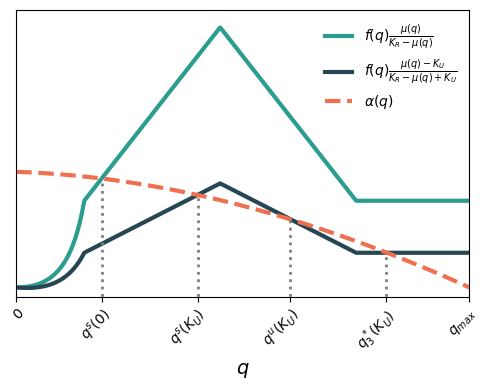

In [9]:
def alpha_RHS(q):
    m = mu(q, q_c, q_max, mu_max)
    return f_saturated(q, q_m, q_n, beta) * m / (K_R - m)

def alpha_RHS_KU(q):
    m = mu(q, q_c, q_max, mu_max)
    return f_saturated(q, q_m, q_n, beta) * (m - K_U) / (K_R - m + K_U)

qs = np.linspace(0, q_max, 1000)
plt.figure(figsize=(5, 4))
plt.plot(qs, alpha_RHS(qs),    lw=3, color='#2a9d8f',
         label=r'$f(q)\frac{\mu(q)}{K_R-\mu(q)}$')
plt.plot(qs, alpha_RHS_KU(qs), lw=3, color='#264653',
         label=r'$f(q)\frac{\mu(q)-K_U}{K_R-\mu(q)+K_U}$')

xmodel = np.arange(105)
plt.plot(xmodel, alpha(xmodel, alpha_params), lw=3, ls='--',
         color='#ef6f51', label=r'$\alpha(q)$')

# Vertical guides at the four equilibrium candidates (paper's Fig. 5)
for q_marker, rhs in [(19, alpha_RHS), (40, alpha_RHS_KU),
                      (60.5, alpha_RHS_KU), (81.5, alpha_RHS_KU)]:
    plt.plot([q_marker, q_marker], [-0.01, float(rhs(q_marker))],
             lw=2, ls=':', color='gray')

plt.xlabel(r'$q$', fontsize=14)
plt.legend(frameon=False)
plt.xlim([0, 100])
plt.ylim([-0.004, 0.12])
plt.xticks([0, 19, 40, 60.5, 81.5, q_max],
           [0, r'$q^s(0)$', r'$q^s(K_U)$', r'$q^u(K_U)$',
            r'$q_3^*(K_U)$', r'$q_{max}$'],
           rotation=45, ha='right', rotation_mode='anchor')
plt.yticks([])
plt.tight_layout()
plt.savefig(fpath('schematic_saturated2.pdf'), format='pdf')
plt.show()


## Timeseries — surge vs. vanishing vs. saturated

Three-phase trajectory (initial transient → U arrives at t=100 → U leaves
at t=300), under three pricing policies. Produces `timeseries_merged.pdf`.


In [11]:
# The timeseries figure uses different arrival rates from the schematic above
K_R_ts, K_U_ts = 4.5, 4.5
X_0 = np.array([50., 0., 15.])

def run_three_phase(rhs, q_n_phase):
    t0 = np.linspace(0,   100,  100)
    t1 = np.linspace(100, 300,  200)
    t2 = np.linspace(300, 1000, 700)
    args0 = (K_R_ts, 0,      q_c, q_max, mu_max, q_m, q_n_phase, beta, alpha_params)
    args1 = (K_R_ts, K_U_ts, q_c, q_max, mu_max, q_m, q_n_phase, beta, alpha_params)
    args2 = args0
    X0p = integrate.odeint(rhs, X_0,       t0, args=args0)
    X1p = integrate.odeint(rhs, X0p[-1],   t1, args=args1)
    X2p = integrate.odeint(rhs, X1p[-1],   t2, args=args2)
    return np.concatenate((t0, t1, t2)), np.concatenate((X0p, X1p, X2p))

t_surge, X_surge = run_three_phase(dX_dt_surge, q_n)         # q_n unused for surge
t_van,   X_van   = run_three_phase(dX_dt_fair,  2 * q_m)     # vanishing floor
t_sat,   X_sat   = run_three_phase(dX_dt_fair,  q_n)         # saturated floor


/var/folders/6m/wzrhnkhs4fgdlg_lb64_mwr40000gp/T/ipykernel_31233/2970347003.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


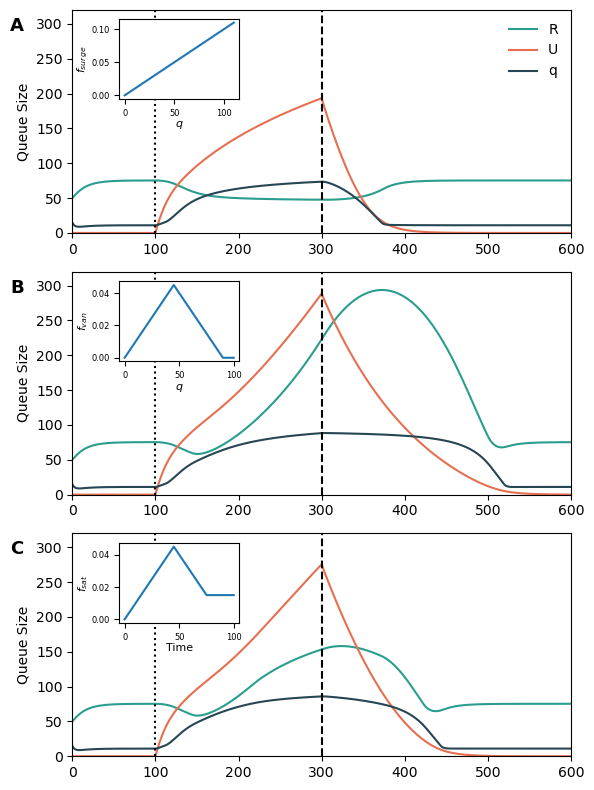

In [12]:
plt.figure(figsize=(6, 8))
panels = [(t_surge, X_surge, True, 'A'),
          (t_van,   X_van,   False, 'B'),
          (t_sat,   X_sat,   False, 'C')]

for idx, (t, X, is_first, idtxt) in enumerate(panels):
    ax = plt.subplot(3, 1, idx + 1)
    plt.plot(t, X[:, 0], c='#2a9d8f', label='R')
    plt.plot(t, X[:, 1], c='#e76f51', label='U')
    plt.plot(t, X[:, 2], c='#264653', label='q')
    plt.plot([100, 100], [0, 400], ls=':',  c='k',
             label=None if is_first else 'U flow initiation')
    plt.plot([300, 300], [0, 400], ls='--', c='k',
             label=None if is_first else 'U flow termination')
    if is_first:
        plt.legend(frameon=False)
    plt.ylabel('Queue Size')
    plt.ylim([0, 320]); plt.xlim([0, 600])
    plt.text(-75, 290, idtxt, fontsize=13, fontweight='bold')
    
    fig=plt.gcf()
    lblsize = 8
    match idtxt:
        case 'A':
            left, bottom, width, height = [0.2, 0.87, 0.2, 0.1]
            ax = fig.add_axes([left, bottom, width, height])
            ax.plot(np.linspace(0, q_max+10, 1000), f_surge(np.linspace(0, q_max+10, 1000), beta))
            ax.set_xlabel(r'$q$', fontsize=lblsize, labelpad=1); ax.set_ylabel(r'$f_{surge}$', fontsize=lblsize, labelpad=1) 
            ax.tick_params(labelsize=6)
        case 'B':
            left, bottom, width, height = [0.2, 0.542, 0.2, 0.1]
            ax = fig.add_axes([left, bottom, width, height])
            ax.plot(qs, f_saturated(qs, q_m, 2*q_m, beta))
            ax.set_xlabel(r'$q$', fontsize=lblsize,labelpad=1); ax.set_ylabel(r'$f_{van}$', fontsize=lblsize, labelpad=1)
            ax.tick_params(labelsize=6)
        case 'C':
            left, bottom, width, height = [0.2, 0.215, 0.2, 0.1]
            ax = fig.add_axes([left, bottom, width, height])
            ax.plot(qs, f_saturated(qs, q_m, q_n, beta))
            ax.set_xlabel(r'$q$', fontsize=lblsize, labelpad=1); ax.set_ylabel(r'$f_{sat}$', fontsize=lblsize, labelpad=1)
            ax.tick_params(labelsize=6)
    
plt.tight_layout()
plt.xlabel('Time')
plt.savefig(fpath('timeseries_merged.pdf'), format='pdf', pad_inches=0)
plt.show()


## Fairness metrics

Produces `fairness.pdf` and `fairness2.pdf`.

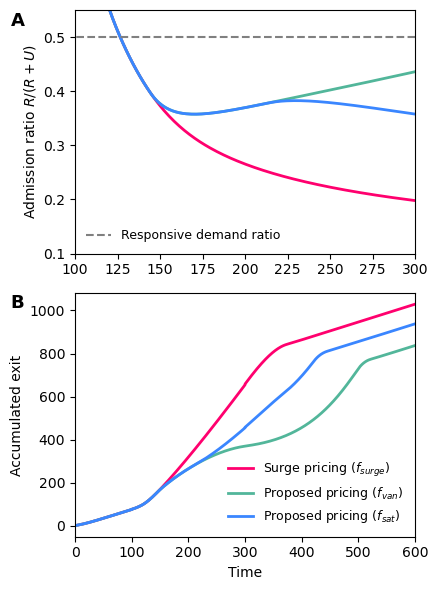

In [14]:
plt.figure(figsize=(4.5, 6))

# Admission ratio R/(R+U)
ax = plt.subplot(2, 1, 1)
t_end = 300
for X, colour in [(X_surge, '#ff006e'), (X_van, '#52b69a'), (X_sat, '#3a86ff')]:
    plt.plot(t_surge[:t_end], X[:t_end, 0] / (X[:t_end, 0] + X[:t_end, 1]),
             c=colour, lw=2)
plt.plot([-5, t_end], [K_R_ts/(K_R_ts + K_U_ts)] * 2,
         c='gray', ls='--', label='Responsive demand ratio')
plt.text(62, .52, 'A', fontsize=13, fontweight='bold')
plt.legend(frameon=False, fontsize=9)
plt.xlim([100, t_end]); plt.ylim([0.10, 0.55])
plt.ylabel(r'Admission ratio $R/(R+U)$')

# Accumulated exit
plt.subplot(2, 1, 2)
t_end = 600
plt.plot(t_surge[:t_end],
         np.cumsum(f_surge(X_surge[:t_end, 2], beta) * X_surge[:t_end, 0]),
         c='#ff006e', lw=2, label=r'Surge pricing ($f_{surge}$)')
plt.plot(t_surge[:t_end],
         np.cumsum(f_saturated(X_van[:t_end, 2], q_m, 2*q_m, beta) * X_van[:t_end, 0]),
         c='#52b69a', lw=2, label=r'Proposed pricing ($f_{van}$)')
plt.plot(t_surge[:t_end],
         np.cumsum(f_saturated(X_sat[:t_end, 2], q_m, q_n, beta) * X_sat[:t_end, 0]),
         c='#3a86ff', lw=2, label=r'Proposed pricing ($f_{sat}$)')
plt.text(-115, 1010, 'B', fontsize=13, fontweight='bold')
plt.legend(frameon=False, fontsize=9)
plt.xlim([0, t_end])
plt.xlabel('Time'); plt.ylabel(r'Accumulated exit')
plt.tight_layout()
plt.savefig(fpath('fairness.pdf'), format='pdf', bbox_inches='tight', pad_inches=0)
plt.show()


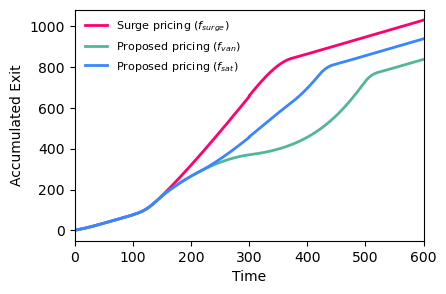

In [15]:
# Standalone accumulated-exit panel
plt.figure(figsize=(4.5, 3))
t_end = 600
plt.plot(t_surge[:t_end],
         np.cumsum(f_surge(X_surge[:t_end, 2], beta) * X_surge[:t_end, 0]),
         c='#ff006e', lw=2, label=r'Surge pricing ($f_{surge}$)')
plt.plot(t_surge[:t_end],
         np.cumsum(f_saturated(X_van[:t_end, 2], q_m, 2*q_m, beta) * X_van[:t_end, 0]),
         c='#52b69a', lw=2, label=r'Proposed pricing ($f_{van}$)')
plt.plot(t_surge[:t_end],
         np.cumsum(f_saturated(X_sat[:t_end, 2], q_m, q_n, beta) * X_sat[:t_end, 0]),
         c='#3a86ff', lw=2, label=r'Proposed pricing ($f_{sat}$)')
plt.legend(frameon=False, fontsize=8)
plt.xlim([0, t_end])
plt.xlabel('Time'); plt.ylabel(r'Accumulated Exit')
plt.savefig(fpath('fairness2.pdf'), format='pdf')
plt.show()
